In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, AutoModel
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [ ]:
train_full = pd.read_csv("data/train.csv")
print(train_full[5:10])
print("\n\n")
print("-" * 50)
print("\n\n")
print(train_full["sentence"].iloc[6])

   id                                           sentence  label
5   5  Jürgen Boos\n\nLäuft nicht auf allen meinen Ge...      2
6   6  I hope they get it togather.\n\nThe design was...      1
7   7  Schön aber naja..\n\nSitzt ein bisschen weit u...      2
8   8  Angenehm zu tragen.\n\nSehr praktisch. Leider ...      3
9   9  Eh - for me, anyway\n\nFeel was ok-ish, didn’t...      1



--------------------------------------------------



I hope they get it togather.

The design was good. The bad part it did not preform, I used an extra att. still not good on SW AIR bands. Will buy another brand.


In [ ]:
train_df, val_df = train_test_split(
        train_full, test_size=0.1, stratify=train_full["label"], random_state=42
)

In [ ]:
# 1. Force recalculate the columns
# handle NaNs with .fillna("") to prevent errors
train_df['word_count'] = train_df['sentence'].fillna("").apply(lambda x: len(str(x).split()))

# 2. Verify the column exists
print(f"Columns in train_df: {train_df.columns.tolist()}")
print(train_df[['sentence', 'word_count']].head())

Columns in train_df: ['id', 'sentence', 'label', 'word_count']
                                                 sentence  word_count
235904  :-)\n\nIch bin sehr zufrieden aber es könnte n...          13
45378   Looks good from a distance, up close- not so m...          60
250228  Schöne Ohrhörer mit Schwächen beim Komfort\n\n...         199
79099   Nach 2 Monaten kaputt!\n\nDer Ring wirkt anfan...          55
156068  Refund, never recieved my package....\n\nI nev...          15


/tmp/ipykernel_233100/1034353939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='label', ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_233100/1034353939.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='word_count', ax=axes[0, 1], palette="magma")


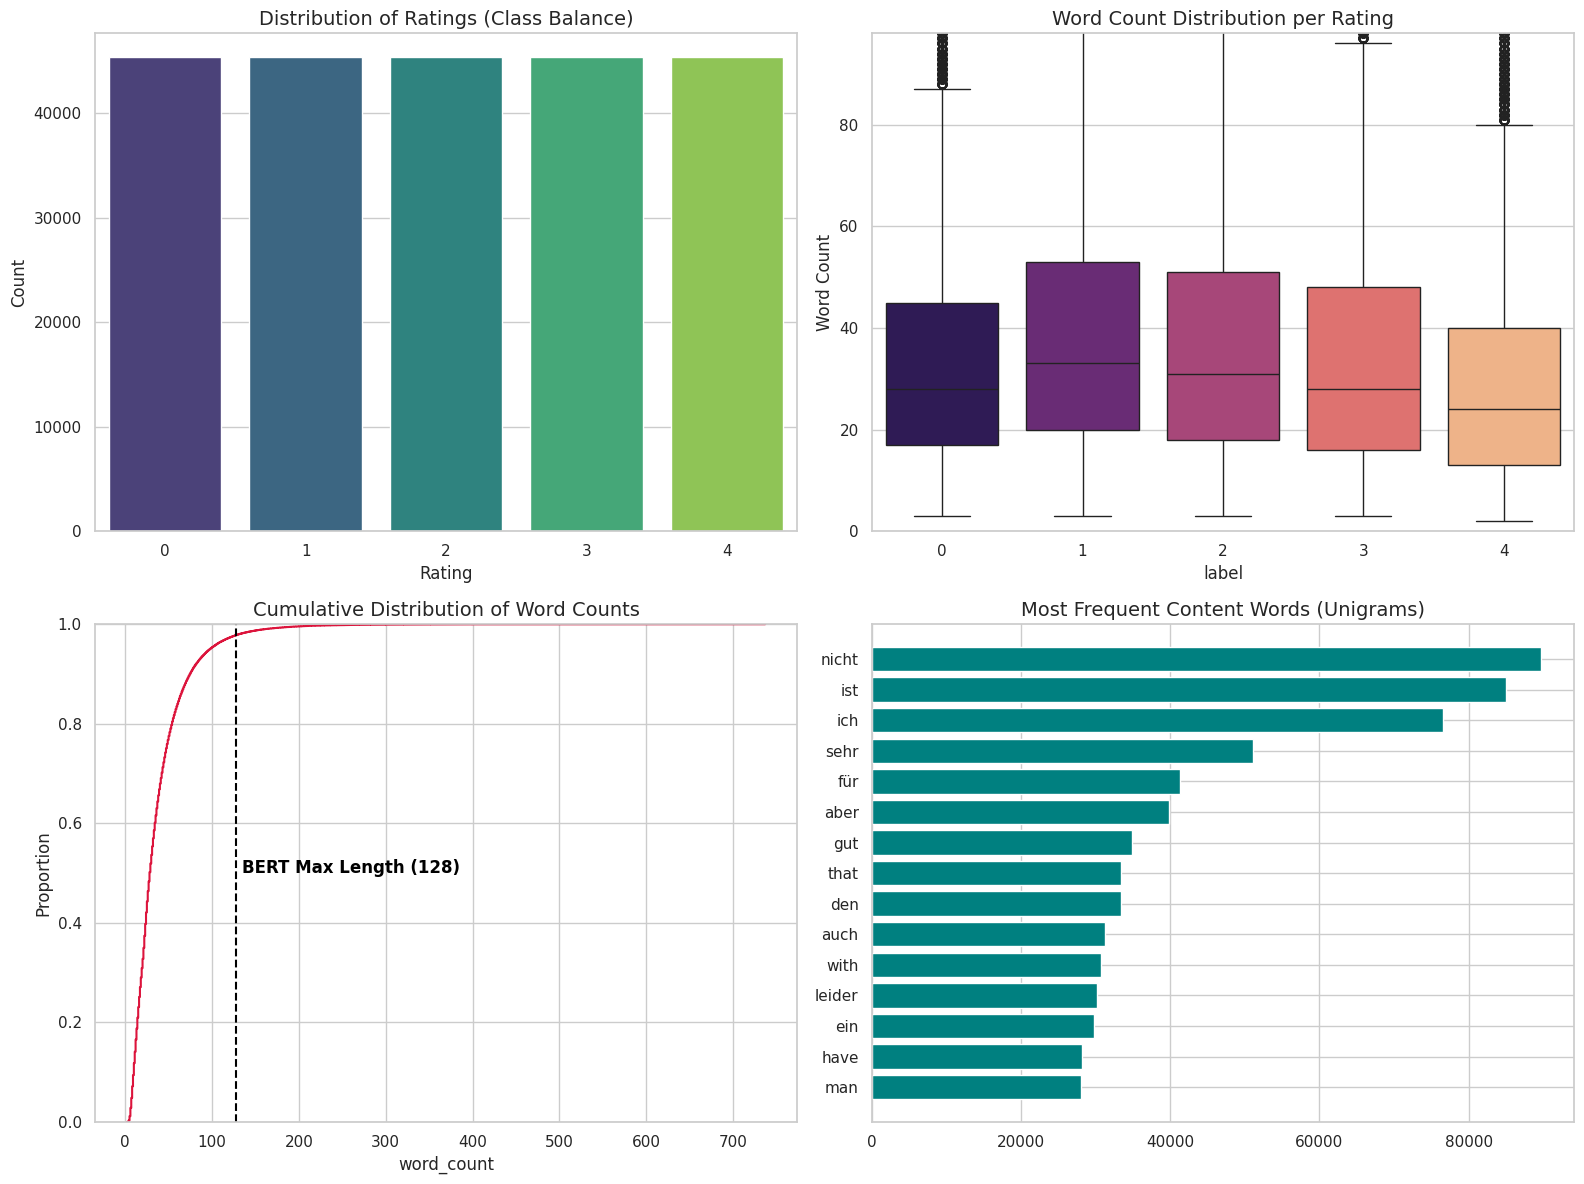

------------------------------
DATASET SUMMARY
------------------------------
Total rows: 226800
Average word count: 37.48
Median word count: 28.00
Conflicting labels (identical text, different rating): 4
------------------------------


In [ ]:
train_full['char_length'] = train_full['sentence'].str.len()
train_full['word_count'] = train_full['sentence'].fillna("").apply(lambda x: len(x.split()))

# Setup visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Rating Distribution (Class Balance) ---
# Critical for choosing your Loss Function (Weighting)
sns.countplot(data=train_df, x='label', ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Distribution of Ratings (Class Balance)", fontsize=14)
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Count")

# --- Plot 2: Word Count per Rating (The 'Angry Wordiness' Check) ---
# Helps identify if length is a predictor for sentiment
sns.boxplot(data=train_df, x='label', y='word_count', ax=axes[0, 1], palette="magma")
axes[0, 1].set_title("Word Count Distribution per Rating", fontsize=14)
axes[0, 1].set_ylim(0, train_df['word_count'].quantile(0.95)) # Clip outliers for visibility
axes[0, 1].set_ylabel("Word Count")

# --- Plot 3: Cumulative Sentence Length (The BERT Limit Check) ---
# If most sentences are > 128 words, your BERT limit is too low
sns.ecdfplot(data=train_df, x='word_count', ax=axes[1, 0], color='crimson')
axes[1, 0].axvline(x=128, color='black', linestyle='--')
axes[1, 0].text(135, 0.5, "BERT Max Length (128)", color='black', fontweight='bold')
axes[1, 0].set_title("Cumulative Distribution of Word Counts", fontsize=14)

# --- Plot 4: Top Keywords (Vocabulary Check) ---
# Quick check of top words (excluding common stop words manually for speed)
def get_top_words(texts, n=15):
    all_text = " ".join(texts).lower()
    words = re.findall(r'\w+', all_text)
    # Simple stopword list
    stops = {'the', 'and', 'is', 'it', 'was', 'to', 'for', 'in', 'of', 'this', 'but', 'not', 'der', 'die', 'das', 'und'}
    words = [w for w in words if w not in stops and len(w) > 2]
    return Counter(words).most_common(n)

top_words = get_top_words(train_df['sentence'].fillna(""))
words, counts = zip(*top_words)
axes[1, 1].barh(words, counts, color='teal')
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Most Frequent Content Words (Unigrams)", fontsize=14)

plt.tight_layout()
plt.show()

# --- 5. Potential Conflict Analysis (Label Noise) ---
duplicates = train_df[train_df.duplicated(subset=['sentence'], keep=False)]
conflicting = duplicates.groupby('sentence')['label'].nunique()
conflict_count = (conflicting > 1).sum()

print("-" * 30)
print(f"DATASET SUMMARY")
print("-" * 30)
print(f"Total rows: {len(train_df)}")
print(f"Average word count: {train_df['word_count'].mean():.2f}")
print(f"Median word count: {train_df['word_count'].median():.2f}")
print(f"Conflicting labels (identical text, different rating): {conflict_count}")
print("-" * 30)

In [2]:
import torch
import numpy as np

def get_stats_incremental(embeddings, mask, batch_size=10000):
    """Calculates mean and covariance for a specific mask using the full tensor."""
    # Pull indices only to avoid large intermediate copies
    indices = torch.where(mask)[0]
    n = len(indices)
    
    # Calculate mean in batches to avoid a massive subset tensor
    sum_vec = torch.zeros(embeddings.shape[1])
    for i in range(0, n, batch_size):
        sum_vec += embeddings[indices[i : i + batch_size]].sum(dim=0)
    mu = sum_vec / n
    
    # Calculate covariance in batches
    cov = torch.zeros((embeddings.shape[1], embeddings.shape[1]))
    for i in range(0, n, batch_size):
        batch = embeddings[indices[i : i + batch_size]] - mu
        cov += torch.mm(batch.t(), batch)
    
    cov /= (n - 1)
    return mu, cov

def whiten_by_language(embeddings, langs):
    # Use float32 for math stability, then cast back if needed
    whitened_embeddings = torch.zeros_like(embeddings)
    unique_langs = np.unique(langs)
    
    for lang in unique_langs:
        print(f"Processing language: {lang}")
        mask = torch.from_numpy(langs == lang) # Ensure same device/type
        
        # 1. Get stats using the fixed incremental function
        mu, cov = get_stats_incremental(embeddings, mask)
        
        # 2. Decomposition
        u, s, _ = torch.svd(cov)
        epsilon = 1e-7
        whitening_mat = u @ torch.diag(1.0 / torch.sqrt(s + epsilon)) @ u.t()
        
        # 3. Apply transformation in batches to the original mask locations
        indices = torch.where(mask)[0]
        batch_size = 10000
        for i in range(0, len(indices), batch_size):
            idx_batch = indices[i : i + batch_size]
            centered_batch = embeddings[idx_batch] - mu
            whitened_embeddings[idx_batch] = centered_batch @ whitening_mat
            
    return whitened_embeddings

# Execute
data = torch.load('data/bert_embeddings_lang.pt')
data['embedding'] = whiten_by_language(data['embedding'], np.array(data['lang']))

Processing language: deu_Latn
Processing language: eng_Latn


In [ ]:
torch.save(data, 'data/bert_embeddings_lang_whitened.pt')

: 

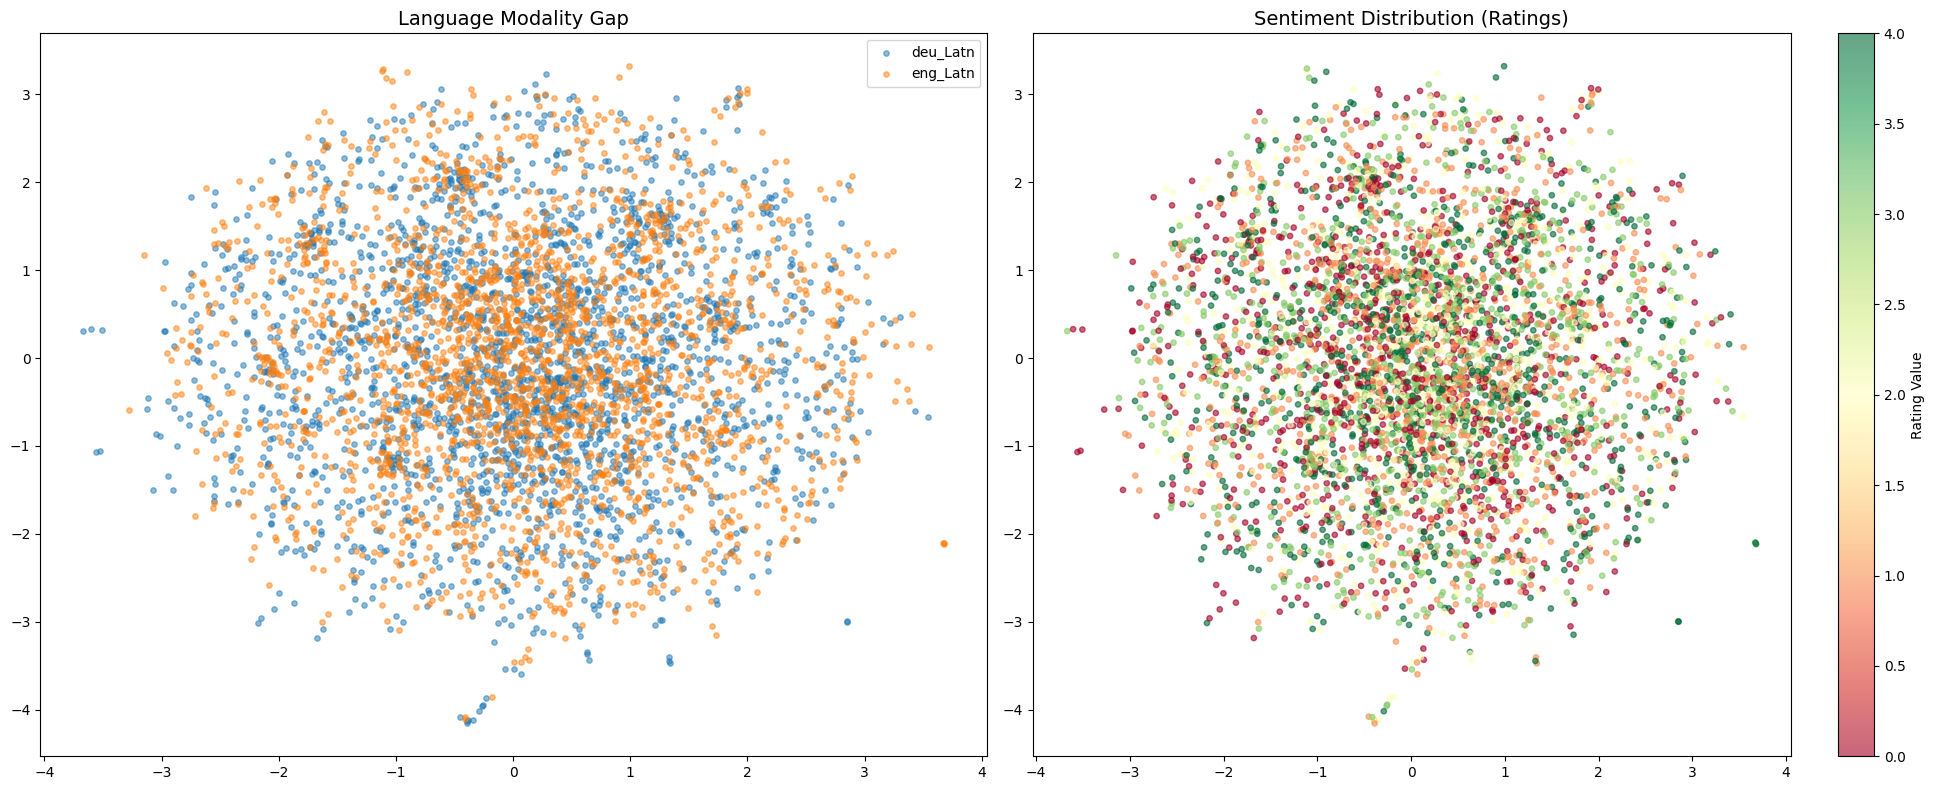

In [3]:
subset_size = 5000
indices = torch.randperm(len(data['id']))[:subset_size].tolist()

X = data['embedding'][indices].numpy()
langs = np.array([data['lang'][i] for i in indices])
ratings = np.array([data['label'][i] for i in indices]) # Assuming 'rating' key exists

# 2. Run t-SNE
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left Plot: Language Clusters
for lang in np.unique(langs):
    mask = langs == lang
    ax1.scatter(X_embedded[mask, 0], X_embedded[mask, 1], label=lang, alpha=0.5, s=15)
ax1.set_title("Language Modality Gap", fontsize=14)
ax1.legend()

# Right Plot: Sentiment/Rating Distribution
# Using 'RdYlGn' (Red-Yellow-Green) is intuitive for ratings/sentiment
scatter = ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=ratings, cmap='RdYlGn', alpha=0.6, s=15)
ax2.set_title("Sentiment Distribution (Ratings)", fontsize=14)
plt.colorbar(scatter, ax=ax2, label='Rating Value')

plt.tight_layout()
plt.show()

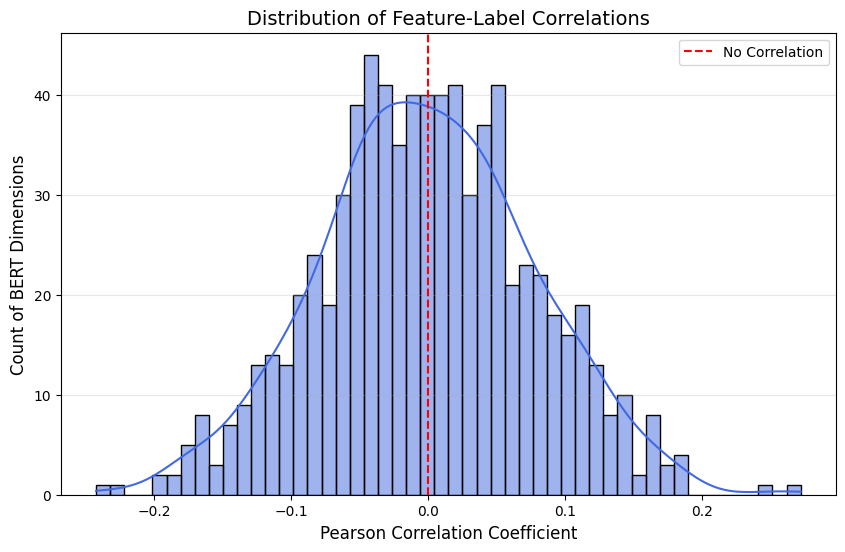

Total Dimensions: 768
Dimensions with |r| > 0.2: 4
Dimensions with |r| > 0.4: 0


In [13]:
X_np = X.numpy()
y_np = y.numpy()

correlations = []
for i in range(X_np.shape[1]):
    # np.corrcoef returns a 2x2 matrix; [0,1] is the cross-correlation
    c = np.corrcoef(X_np[:, i], y_np)[0, 1]
    correlations.append(c)

correlations = np.array(correlations)

# 3. Sort by ABSOLUTE value to find the most influential features
# (regardless of whether they correlate positively or negatively)
abs_idx = np.argsort(np.abs(correlations))[::-1]

plt.figure(figsize=(10, 6))
sns.histplot(correlations, bins=50, kde=True, color='royalblue')

# Add a vertical line at 0 for reference
plt.axvline(x=0, color='red', linestyle='--', label='No Correlation')

plt.title('Distribution of Feature-Label Correlations', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Count of BERT Dimensions', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Print spread statistics
print(f"Total Dimensions: {len(correlations)}")
print(f"Dimensions with |r| > 0.2: {np.sum(np.abs(correlations) > 0.2)}")
print(f"Dimensions with |r| > 0.4: {np.sum(np.abs(correlations) > 0.4)}")

In [3]:
import pandas as pd
import fasttext
from huggingface_hub import hf_hub_download

# 1. Load data
df = pd.read_csv('data/train.csv')

# 2. Load model
lang_model = fasttext.load_model("data/model.bin")

def get_lang_batches(df, column='sentence', batch_size=10000):
    results = []
    cleaned_col = df[column].fillna("").str.replace("\n", " ")
    
    # Define your allowed set
    allowed_langs = {'deu_Latn', 'eng_Latn'}
    
    for i in range(0, len(cleaned_col), batch_size):
        batch = cleaned_col.iloc[i:i+batch_size].tolist()
        
        # Increase k to ensure we catch 'de' or 'en' if they aren't the #1 guess
        # k=5 is usually enough to find a secondary correct language
        labels, _ = lang_model.predict(batch, k=10)
        
        for sample_labels in labels:
            # Clean labels
            clean_labels = [l.replace("__label__", "") for l in sample_labels]
            #print(clean_labels)
            # Find the first label that is in our allowed set
            match = next((l for l in clean_labels if l in allowed_langs), "other")
            results.append(match)
            
    return results

df['lang'] = get_lang_batches(df)
df.to_csv('data/train_lang.csv', index=False)

In [4]:
import torch
import pandas as pd

# 1. Load the CSV (the "Ground Truth" for order)
df = pd.read_csv('data/train_lang.csv')

# 2. Load the embeddings (Assuming they are just a tensor or a dict with 'embeddings')
# map_location='cpu' is critical to avoid OOM
raw_data = torch.load('data/train_bert_features_mean.pt', map_location='cpu')

# Extract the tensor
if isinstance(raw_data, dict):
    emb_tensor = raw_data['embeddings']
else:
    emb_tensor = raw_data

# 3. Validation Check
if len(df) != emb_tensor.size(0):
    raise ValueError(f"Size mismatch! CSV has {len(df)} rows, but Tensor has {emb_tensor.size(0)} rows.")

# 4. Create the final file step-by-step to save RAM
data_to_save = {}

# Move to float32 and add to dict (do this in one line to help garbage collection)
data_to_save['embedding'] = emb_tensor.to(torch.float32)
del raw_data # Free the original immediately

# Add metadata from the DataFrame
data_to_save['id'] = torch.tensor(df['id'].values)
data_to_save['lang'] = df['lang'].tolist()
data_to_save['label'] = torch.tensor(df['label'].values, dtype=torch.long)

# 5. Final Save
torch.save(data_to_save, 'data/bert_embeddings_lang.pt')
print("Successfully merged using implicit row ordering.")

Successfully merged using implicit row ordering.
